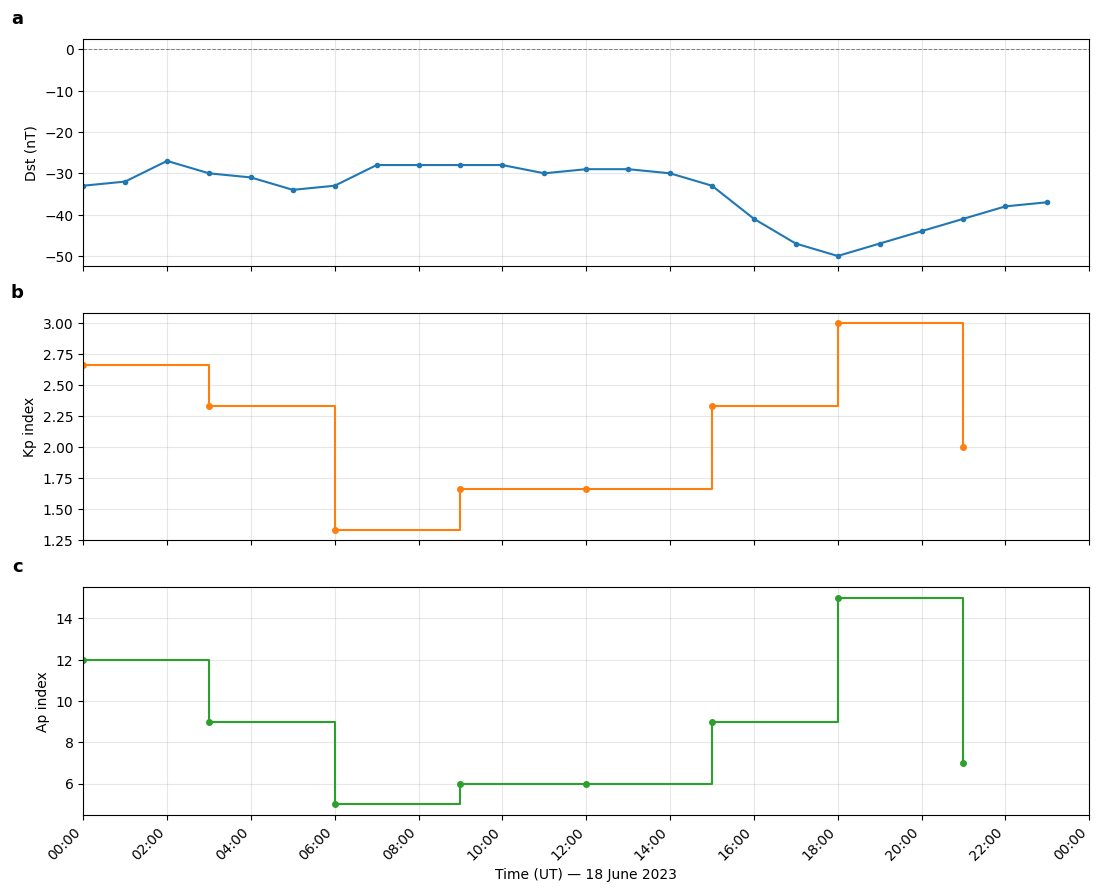

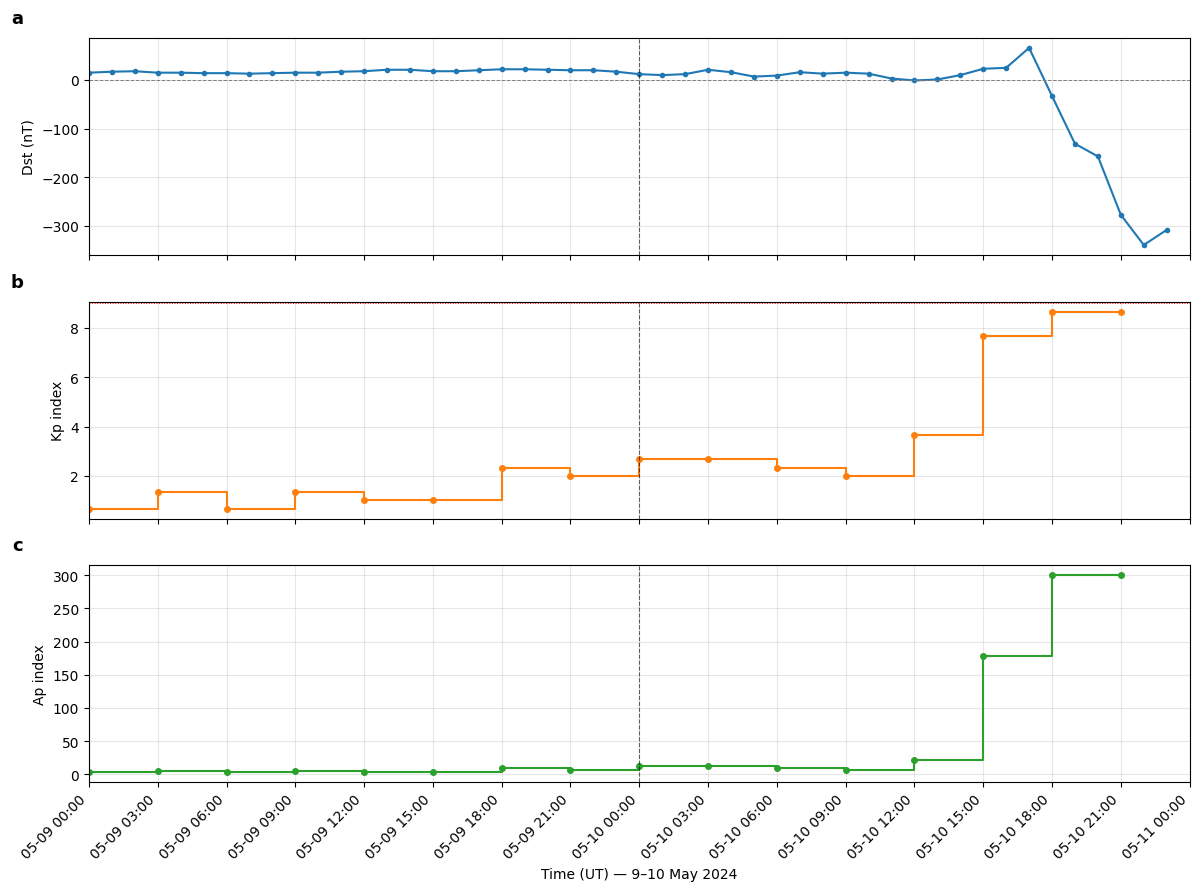

Done


In [2]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

# ---------------- Data ----------------
dst_18th_june_2023 = [-33, -32, -27, -30, -31, -34, -33, -28, -28, -28, -28, -30, -29, -29, -30, -33, -41, -47, -50, -47, -44, -41, -38, -37]
dst_9th_may_2024   = [15, 17, 18, 15, 15, 14, 14, 13, 14, 15, 15, 17, 18, 21, 21, 18, 18, 20, 22, 22, 21, 20, 20, 17]
dst_10th_may_2024  = [12, 10, 12, 21, 16, 7, 9, 16, 13, 15, 13, 3, -1, 1, 10, 23, 25, 66, -33, -131, -157, -277, -339, -308]

kp_18th_june_2023 = [2.667, 2.333, 1.333, 1.667, 1.667, 2.333, 3.000, 2.000]
kp_9th_may_2024   = [0.667, 1.333, 0.667, 1.333, 1.000, 1.000, 2.333, 2.000]
kp_10th_may_2024  = [2.667, 2.667, 2.333, 2.000, 3.667, 7.667, 8.667, 8.667]

ap_18th_june_2023 = [12, 9, 5, 6, 6, 9, 15, 7]
ap_9th_may_2024   = [3, 5, 3, 5, 4, 4, 9, 7]
ap_10th_may_2024  = [12, 12, 9, 7, 22, 179, 300, 300]

# ---------------- Helper to build time axes ----------------
def hourly_times(start_date, n):
    return [start_date + timedelta(hours=i) for i in range(n)]

def three_hourly_times(start_date, n):
    return [start_date + timedelta(hours=3*i) for i in range(n)]

# ================= Plot 1: 18 June 2023 =================
day_a = datetime(2023, 6, 18)

dst_times_a = hourly_times(day_a, 24)
kpap_times_a = three_hourly_times(day_a, 8)

fig1, axes1 = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

axes1[0].plot(dst_times_a, dst_18th_june_2023, color='#1f77b4', marker='o', markersize=3)
axes1[0].set_ylabel("Dst (nT)")
axes1[0].axhline(0, color='gray', linewidth=0.7, linestyle='--')
axes1[0].grid(alpha=0.3)

axes1[1].step(kpap_times_a, kp_18th_june_2023, where='post', color='#ff7f0e', marker='o', markersize=4)
axes1[1].set_ylabel("Kp index")
axes1[1].grid(alpha=0.3)

axes1[2].step(kpap_times_a, ap_18th_june_2023, where='post', color='#2ca02c', marker='o', markersize=4)
axes1[2].set_ylabel("Ap index")
axes1[2].grid(alpha=0.3)

axes1[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes1[2].xaxis.set_major_locator(mdates.HourLocator(interval=2))
axes1[2].set_xlabel("Time (UT) — 18 June 2023")
axes1[2].set_xlim(day_a, day_a + timedelta(hours=24))

for ax, label in zip(axes1, ['a', 'b', 'c']):
    ax.text(-0.06, 1.05, label, transform=ax.transAxes,
            fontsize=13, fontweight='bold',
            va='bottom', ha='right')

fig1.autofmt_xdate(rotation=45)
fig1.tight_layout()

# Save and display
fig1.savefig("geomag_18june2023.png", dpi=150, bbox_inches="tight")
plt.show()

# ================= Plot 2: 9-10 May 2024 =================
day_b = datetime(2024, 5, 9)

dst_times_b = hourly_times(day_b, 48)
dst_values_b = dst_9th_may_2024 + dst_10th_may_2024

kpap_times_b = three_hourly_times(day_b, 16)
kp_values_b = kp_9th_may_2024 + kp_10th_may_2024
ap_values_b = ap_9th_may_2024 + ap_10th_may_2024

fig2, axes2 = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes2[0].plot(dst_times_b, dst_values_b, color='#1f77b4', marker='o', markersize=3)
axes2[0].set_ylabel("Dst (nT)")
axes2[0].axhline(0, color='gray', linewidth=0.7, linestyle='--')
axes2[0].grid(alpha=0.3)

axes2[1].step(kpap_times_b, kp_values_b, where='post', color='#ff7f0e', marker='o', markersize=4)
axes2[1].set_ylabel("Kp index")
axes2[1].axhline(9, color='red', linewidth=0.7, linestyle=':')
axes2[1].grid(alpha=0.3)

axes2[2].step(kpap_times_b, ap_values_b, where='post', color='#2ca02c', marker='o', markersize=4)
axes2[2].set_ylabel("Ap index")
axes2[2].grid(alpha=0.3)

midnight = datetime(2024, 5, 10)
for ax in axes2:
    ax.axvline(midnight, color='black', linewidth=0.8,
               linestyle='--', alpha=0.6)

axes2[2].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
axes2[2].xaxis.set_major_locator(mdates.HourLocator(interval=3))
axes2[2].set_xlabel("Time (UT) — 9–10 May 2024")
axes2[2].set_xlim(day_b, day_b + timedelta(hours=48))

for ax, label in zip(axes2, ['a', 'b', 'c']):
    ax.text(-0.06, 1.05, label, transform=ax.transAxes,
            fontsize=13, fontweight='bold',
            va='bottom', ha='right')

fig2.autofmt_xdate(rotation=45)
fig2.tight_layout()

# Save and display
fig2.savefig("geomag_9_10may2024.png", dpi=150, bbox_inches="tight")
plt.show()

print("Done")